# Deal with nested grids

In Marthe, grid domain can be refined locally. In this case, special method are required for visualisation.
This tutorial aim to show the main function to plot such nested grids.

## Load grid

Nested grids are loaded by `gridmarthe` just as any Marthe grid.

In [12]:
import gridmarthe as gm
ds = gm.load_marthe_grid('nested.permh', drop_nan=True, nanval=[0., -9999.])

In this case, data are stored in 1D (only 1 timestep here). The vector is composed by data from
maingrid then nested grid 1, nested grid 2 and nested grid 3. Each value of the vector is associated
with an index (the `zone` dimension), linked to a couple of coordinates.

If we assign coords and plot the dataset, the non-continuous coordinates (dx and dy are not constant)
lead to poor visualisation with matplotlib base `pcolormesh`.

In [13]:
# assign coords 
ds2d = ds.mart.assign_coords().isel(time=0)

## Naive plot

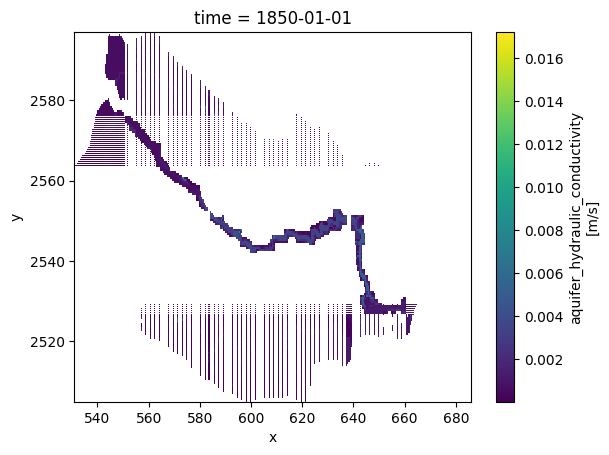

In [14]:
import matplotlib.pyplot as plt
ds2d['permeab'].plot.pcolormesh(x='x', y='y')
plt.show()

## Gridmarthe helper

gridmarthe provide a helper function to plot such grids (which can accept keywords argument from `xarray.Dataset.plot.pcolormesh`)

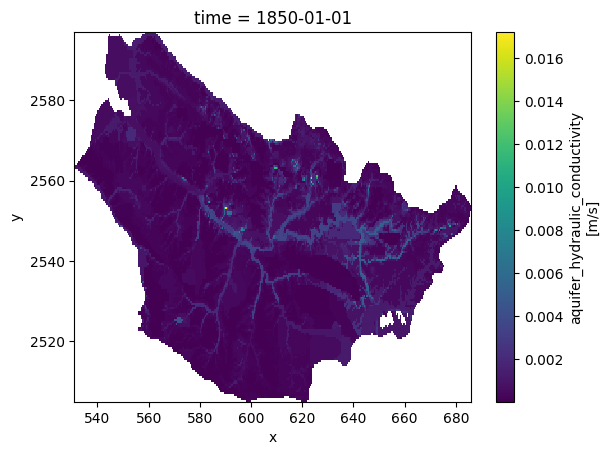

In [15]:
gm.plot_nested_grid(ds2d, var='permeab')
plt.show()